Running Monty Hall Simulation |████████████████████████████████████████| 10000/10000 [100%] in 0.0s (307627.94/s) 

Final Stay Probability: 0.3338
Final Switch Probability: 0.6662


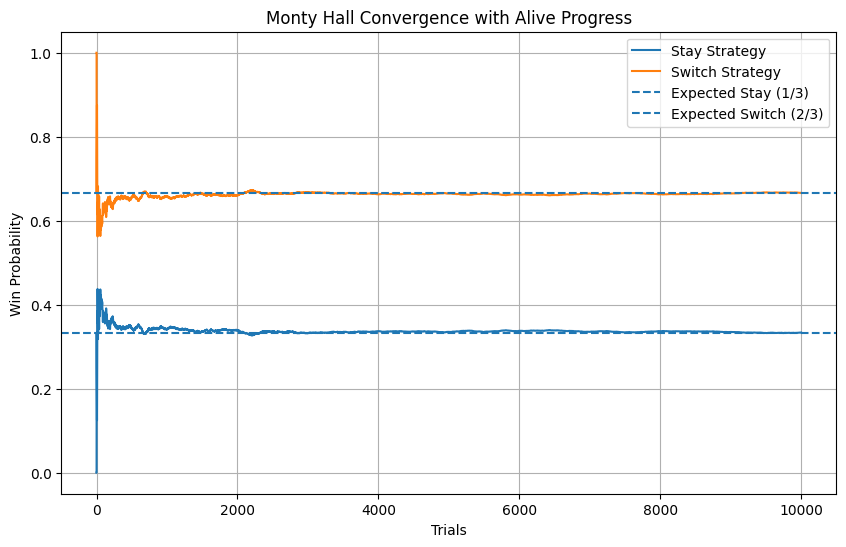

In [ ]:
import argparse
import logging
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from alive_progress import alive_bar
from matplotlib import animation


def monty_hall_simulation(n_trials, n_doors=3):
    if n_doors < 3:
        raise ValueError("n_doors must be >= 3")

    stay_wins = 0
    switch_wins = 0

    stay_probs = []
    switch_probs = []

    with alive_bar(n_trials, title="Running Monty Hall Simulation") as bar:
        for i in range(1, n_trials + 1):
            doors = [0] * n_doors
            prize = random.randrange(n_doors)
            doors[prize] = 1

            choice = random.randrange(n_doors)

            possible_opens = [d for d in range(n_doors) if d != choice and d != prize]
            if not possible_opens:
                raise RuntimeError("No valid door for host to open, check algorithm")
            host_opens = random.choice(possible_opens)

            switch_choice = next(d for d in range(n_doors) if d not in {choice, host_opens})

            stay_wins += int(doors[choice] == 1)
            switch_wins += int(doors[switch_choice] == 1)

            stay_probs.append(stay_wins / i)
            switch_probs.append(switch_wins / i)

            bar()

    return stay_probs, switch_probs


def plot_results(stay_probs, switch_probs, save_path=None):
    plt.figure(figsize=(12, 7))

    plt.plot(stay_probs, label='Stay Strategy', color='tab:blue', alpha=0.8)
    plt.plot(switch_probs, label='Switch Strategy', color='tab:orange', alpha=0.8)

    plt.axhline(y=1/3, linestyle='--', color='tab:blue', label='Expected Stay (1/3)')
    plt.axhline(y=2/3, linestyle='--', color='tab:orange', label='Expected Switch (2/3)')

    plt.xlabel("Trials")
    plt.ylabel("Win Probability")
    plt.title("Monty Hall Strategy Convergence")
    plt.legend()
    plt.grid(alpha=0.3)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        logging.info('Saved plot to %s', save_path)

    plt.show()


def animate_results(stay_probs, switch_probs, output_file='monty_hall_animation.gif', interval=25):
    fig, ax = plt.subplots(figsize=(12, 7))

    line_stay, = ax.plot([], [], lw=2, label='Stay Strategy', color='tab:blue')
    line_switch, = ax.plot([], [], lw=2, label='Switch Strategy', color='tab:orange')
    expected_stay = ax.axhline(1 / 3, linestyle='--', color='tab:blue', alpha=0.5)
    expected_switch = ax.axhline(2 / 3, linestyle='--', color='tab:orange', alpha=0.5)

    ax.set_xlim(0, len(stay_probs))
    ax.set_ylim(0, 1)
    ax.set_xlabel("Trials")
    ax.set_ylabel("Win Probability")
    ax.set_title("Monty Hall Simulation Live Convergence")
    ax.grid(alpha=0.3)
    ax.legend()

    def init():
        line_stay.set_data([], [])
        line_switch.set_data([], [])
        return line_stay, line_switch

    def update(frame):
        x = list(range(frame + 1))
        line_stay.set_data(x, stay_probs[: frame + 1])
        line_switch.set_data(x, switch_probs[: frame + 1])
        return line_stay, line_switch

    ani = animation.FuncAnimation(fig, update, frames=len(stay_probs), init_func=init, blit=True, interval=interval)

    try:
        writer = animation.PillowWriter(fps=1000 / interval)
        ani.save(output_file, writer=writer)
        logging.info('Saved animation to %s', output_file)
    except Exception as exc:
        logging.warning('Animation save failed: %s', exc)

    plt.close(fig)


def parse_args():
    parser = argparse.ArgumentParser(description='Monty Hall simulation with plotting+animation')
    parser.add_argument('--trials', type=int, default=10000, help='Number of trials to run')
    parser.add_argument('--doors', type=int, default=3, help='Number of doors (>=3)')
    parser.add_argument('--save-plot', type=str, default='monty_hall_plot.png', help='Output plot file path')
    parser.add_argument('--no-show', action='store_true', help='Do not show interactive plot')
    parser.add_argument('--animate', action='store_true', help='Save a GIF animation of convergence')
    parser.add_argument('--animation-output', type=str, default='monty_hall_animation.gif', help='GIF output path')
    return parser.parse_args()


def main():
    args = parse_args()
    logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

    stay_probs, switch_probs = monty_hall_simulation(args.trials, n_doors=args.doors)

    print(f"Final Stay Probability: {stay_probs[-1]:.4f}")
    print(f"Final Switch Probability: {switch_probs[-1]:.4f}")

    plot_results(stay_probs, switch_probs, save_path=args.save_plot)

    if args.animate:
        animate_results(stay_probs, switch_probs, output_file=args.animation_output)

    if args.no_show:
        plt.close('all')


if __name__ == '__main__':
    main()